## Model-Based Segmentation, Supervised

### Prelude

#### Installs and Imports

In [2]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install focal-loss

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install -U albumentations --no-binary qudida,albumentations

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install segmentation-models

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import albumentations as A
import segmentation_models as sm

import matplotlib.pyplot as  plt
from matplotlib.gridspec import GridSpec

from glob import glob
from random import randint
from skimage.io import imread
from datetime import datetime 
from focal_loss import SparseCategoricalFocalLoss

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import Sequence, load_img
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda, Activation, SeparableConv2D

Segmentation Models: using `keras` framework.


#### Path Assignment

In [7]:
root_dir = '../data/external'
img_path_list = glob(os.path.join(root_dir, 'images/**/*.jpg'))
mask_path_list = [path.replace('images', 'annotations').replace('.jpg', '_mask.png') for path in img_path_list]

In [8]:
path_df = pd.DataFrame({'Img Path': img_path_list, 'Mask Path': mask_path_list})

train_df, test_df = train_test_split(path_df, test_size=0.1, shuffle=False)
train_df, val_df = train_test_split(train_df, test_size=0.2, shuffle=False)

#### Helper Functions

In [34]:
def Patch(img, patch_size):
    patchs = []
    for i in range(0, img.shape[0], patch_size):
        for j in range(0, img.shape[1], patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            patchs.append(patch)
    return np.array(patchs)

def Unpatch(patchs, img_shape):
    row_range = img_shape[0]//patchs.shape[1]
    clmn_range = img_shape[1]//patchs.shape[2]
    patchs_ = np.reshape(patchs, (row_range, clmn_range, *patchs.shape[1:]))

    clmn_stacks = []
    for r_patchs in patchs_:
        clmn_stacks.append(np.concatenate(r_patchs, axis=1))
    return np.concatenate(clmn_stacks, axis=0)

def EncodeLabel(mask, n_classes=3, to_catagorical=True):
    mask_1chnl = np.sum(mask, axis=-1)
    mask_flat = mask_1chnl.reshape((-1))

    Encoder = LabelEncoder()
    encoded_mask = Encoder.fit_transform(mask_flat) # [0 176 255] to [0 1 2]
    encoded_mask = encoded_mask.reshape(mask_1chnl.shape)
    if to_catagorical:
        encoded_mask = to_categorical(encoded_mask, num_classes=n_classes, dtype='int8')
    return encoded_mask

def Normalize(img):
    Scaler = MinMaxScaler()
#     flat_img = img.reshape((-1))
    flat_img = img.reshape((-1, 3))  # MinMaxScaler requires 2D array
    normalized_img = Scaler.fit_transform(flat_img) # 0-255 to 0-1
    normalized_img = normalized_img.reshape(img.shape)
    return normalized_img

def EncodeCatLabel(mask, n_classes=None):
    n_classes = len(np.unique(mask)) if n_classes==None else n_classes
    mask_1chnl = np.sum(mask, axis=-1)
    cat_encoded = np.empty(shape=(*mask_1chnl.shape, n_classes))

    for i, value in enumerate(np.unique(mask_1chnl)):
        cat_encoded[mask_1chnl==value, i] = 1        
    return cat_encoded.astype('float32')

#### Visualize Image Patching and Unpatching

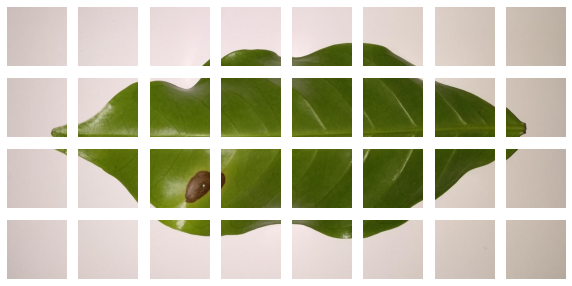

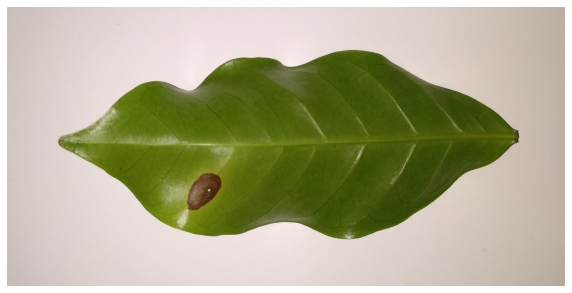

In [12]:
idx = randint(0, len(img_path_list))
patch_size=256

img = cv2.cvtColor(cv2.imread(img_path_list[idx]), cv2.COLOR_BGR2RGB)

patched_img = Patch(img, patch_size)
unpatched_img = Unpatch(patched_img, img.shape)

ncols, nrows = img.shape[1]//patch_size, img.shape[0]//patch_size

gs = GridSpec(nrows, ncols)
fig1 = plt.figure(figsize=(10, 5))
for r in range(nrows):
    for c in range(ncols):
        ax = fig1.add_subplot(gs[r, c])
        ax.imshow(patched_img[(r*ncols+c)])
        ax.axis('off')

plt.figure(figsize=(10, 6))
plt.imshow(unpatched_img)
plt.axis('off')

plt.show()

#### Custom Data Generator

In [39]:
class DataGenerator(Sequence):

    def __init__(self, df, patch_size, shuffle=True):
        self.df = df.copy()
        self.patch_size = patch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))

        self.on_epoch_end()

    def __len__(self):
        img_path = self.df['Img Path'].iloc[randint(0, len(self.df))]
        img_shape = imread(img_path).shape
        batch_size = (img_shape[0] * img_shape[1]) // (self.patch_size ** 2)
        return batch_size

    def on_epoch_end(self):
        if self.shuffle == True:
            np.random.shuffle(self.indexes)
            return self.df.reindex(self.indexes)
    
    def __getitem__(self, index):
        img_path = self.df['Img Path'].iloc[index]
        mask_path = self.df['Mask Path'].iloc[index]

        img, mask = imread(img_path), imread(mask_path)             # loads rgb image
        
        transform = A.Compose([A.RandomBrightnessContrast(p=0.25),
                               A.HorizontalFlip(p=0.25),
                               A.VerticalFlip(p=0.25),
                               A.Blur(p=0.25)])

        augmented = transform(image=img, mask=mask)
        augmented_img, augmented_mask = augmented['image'], augmented['mask']

        normalized_img = Normalize(augmented_img)
        encoded_mask = EncodeCatLabel(augmented_mask)

        patched_img, patched_mask = Patch(normalized_img, self.patch_size), Patch(encoded_mask, self.patch_size)     
        return patched_img, patched_mask

#### Custom Metrics and Losses

In [14]:
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1.0)


def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

# def jacard_coef(y_true, y_pred):
#     y_true_f = K.flatten(y_true)
#     y_pred_f = K.flatten(y_pred)
#     intersection = K.sum(y_true_f * y_pred_f)
#     return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)


# def jacard_coef_loss(y_true, y_pred):
#     return -jacard_coef(y_true, y_pred)

### Segmenatation Using UNet

#### Vanilla Unet Model

In [28]:
def ConvBlock(input, n_filters, set_batchnorm, dropout):
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(input)
    if set_batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
    if set_batchnorm:
        x = BatchNormalization()(x)    
    x = Activation('relu')(x)
    if dropout > 0:
        x = Dropout(dropout)(x)
    return x

def EncoderBlock(input, n_filters, set_batchnorm, dropout):
    x = ConvBlock(input, n_filters, set_batchnorm, dropout)
    p = MaxPooling2D((2, 2))(x)
    return x, p

def DecoderBlock(input, skip_features, n_filters, set_batchnorm, dropout):
    x = Conv2DTranspose(n_filters, (2, 2), strides=2, padding='same')(input)
    x = concatenate([x, skip_features])
    x = ConvBlock(x, n_filters, set_batchnorm, dropout)
    return x


def Unet(input_shape, n_classes, n_filters, set_batchnorm, dropout):
    inputs = Input(input_shape)

    conv1, pool1 = EncoderBlock(inputs, n_filters, set_batchnorm, dropout)
    conv2, pool2 = EncoderBlock(pool1, n_filters*2, set_batchnorm, dropout)
    conv3, pool3 = EncoderBlock(pool2, n_filters*4, set_batchnorm, dropout)
    conv4, pool4 = EncoderBlock(pool3, n_filters*8, set_batchnorm, dropout)

    midconv = ConvBlock(pool4, n_filters*16, set_batchnorm, dropout) # Bottleneck layer

    deconv1 = DecoderBlock(midconv, conv4, n_filters*8, set_batchnorm, dropout)
    deconv2 = DecoderBlock(deconv1, conv3, n_filters*4, set_batchnorm, dropout)
    deconv3 = DecoderBlock(deconv2, conv2, n_filters*2, set_batchnorm, dropout)
    deconv4 = DecoderBlock(deconv3, conv1, n_filters, set_batchnorm, dropout)

    outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(deconv4)

    model = Model(inputs, outputs, name='Vanilla_UNet')
    return model

In [29]:
model = Unet(input_shape=(256, 256, 3), n_classes=3, n_filters=64, set_batchnorm=False, dropout=0.2)
model.summary()

Model: "Vanilla_UNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_38 (Conv2D)             (None, 256, 256, 64  1792        ['input_3[0][0]']                
                                )                                                                 
                                                                                                  
 activation_36 (Activation)     (None, 256, 256, 64  0           ['conv2d_38[0][0]']              
                                )                                                      

#### Compile and Train

In [40]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.001,
                               decay_steps=118,#################### Modify as you see fit
                               decay_rate=0.97,
                               staircase=True)
 
model.compile(loss=dice_coef_loss,
            #   loss=SparseCategoricalFocalLoss(gamma=2),
              optimizer= Adam(learning_rate=lr_schedule),
              metrics=['accuracy', dice_coef])

In [41]:
train_generator = DataGenerator(df=train_df, patch_size=256, shuffle=True)
val_generator = DataGenerator(df=val_df, patch_size=256, shuffle=True)
test_generator = DataGenerator(df=test_df, patch_size=256, shuffle=True)

In [ ]:
num_epochs = 4
check_point = ModelCheckpoint(filepath='./Checkpoints',
                              monitor='val_dice_coef_loss',
                              verbose=1,
                              save_best_only=True,
                              mode='auto',
                              save_freq='epoch')
                              
early_stop = EarlyStopping(monitor='val_dice_coef_loss',
                           min_delta=0.001,
                           patience=2,
                           verbose=1)
                           
start = datetime.now() 

hist = model.fit(train_generator,
                 epochs = num_epochs,
                 verbose=2,
                 validation_data = val_generator,
                 callbacks = [check_point, early_stop])   


stop = datetime.now()
execution_time= stop - start
print(f'Execution time: {execution_time}')

model.save('./SavedModel')                              

In [ ]:
loss, acc = model.evaluate(test_generator, verbose=0)
print("    Test Loss: {:.5f}".format(loss))
print("Test Accuracy: {:.2f}%".format(acc * 100))

### Segmentation Using DeepLabV3+

### Segmentation Using Segmentation Models

## Model Based Segmentation, Unsupervised

In [ ]:
# def ConvBlock(inputs, n_filters, separable, dropout):
#     if separable:
#         return Sequential(
#             [   
#                 inputs,
#                 SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#                 SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#             ]
#         )
#     else:
#         return Sequential(
#             [   
#                 inputs,
#                 Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#                 Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal'),
#                 BatchNormalization(),
#                 Activation('relu'),
#                 Dropout(dropout),
#             ]
#         )


def ConvBlock(inputs, n_filters, separable=True, dropout=0.3):
    if separable:
        x = SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(inputs)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)

        x = SeparableConv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)
        return x

    else:
        x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(inputs)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)

        x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(dropout)(x)
        return x

def EncoderBlock(inputs, n_filters, separable, dropout):
    x = ConvBlock(inputs, n_filters, separable, dropout)
    p = MaxPooling2D((2, 2))(x)
    return x, p


def DecoderBlock(inputs, skip_features, n_filters, separable, dropout):
    x = UpSampling2D(size=(2, 2), data_format='channels_last')(inputs)
    x = concatenate([x, skip_features])
    x = ConvBlock(x, n_filters, separable, dropout)
    return x

# def WNet(input_shape, n_classes, n_filters, separable, dropout=0.3):
def WNet(input_shape=(256, 256, 3), n_classes=3, n_filters=64):    
    inputs = Input(input_shape)
    
    UEnc_conv1, UEnc_pool1 = EncoderBlock(inputs, n_filters, separable=False, dropout=0.3)
    UEnc_conv2, UEnc_pool2 = EncoderBlock(UEnc_pool1, n_filters*2, separable=True, dropout=0.3)
    UEnc_conv3, UEnc_pool3 = EncoderBlock(UEnc_pool2, n_filters*4, separable=True, dropout=0.3)
    UEnc_conv4, UEnc_pool4 = EncoderBlock(UEnc_pool3, n_filters*8, separable=True, dropout=0.3)

    UEnc_midconv = ConvBlock(UEnc_pool4, n_filters*16, separable=True, dropout=0.3) # Bottleneck layer
    
    UEnc_deconv1 = DecoderBlock(UEnc_midconv, UEnc_conv4, n_filters*8, separable=True, dropout=0.3)
    UEnc_deconv2 = DecoderBlock(UEnc_deconv1, UEnc_conv3, n_filters*4, separable=True, dropout=0.3)
    UEnc_deconv3 = DecoderBlock(UEnc_deconv2, UEnc_conv2, n_filters*2, separable=True, dropout=0.3)
    UEnc_deconv4 = DecoderBlock(UEnc_deconv3, UEnc_conv1, n_filters, separable=False, dropout=0.3)  

    UEnc_outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(UEnc_deconv4)


    UDec_conv1, UDec_pool1 = EncoderBlock(UEnc_outputs, n_filters, separable=False, dropout=0.3)
    UDec_conv2, UDec_pool2 = EncoderBlock(UDec_pool1, n_filters*2, separable=True, dropout=0.3)
    UDec_conv3, UDec_pool3 = EncoderBlock(UDec_pool2, n_filters*4, separable=True, dropout=0.3)
    UDec_conv4, UDec_pool4 = EncoderBlock(UDec_pool3, n_filters*8, separable=True, dropout=0.3)

    UDec_midconv = ConvBlock(UDec_pool4, n_filters*16, separable=True, dropout=0.3) # Bottleneck layer

    UDec_deconv1 = DecoderBlock(UDec_midconv, UDec_conv4, n_filters*8, separable=True, dropout=0.3)
    UDec_deconv2 = DecoderBlock(UDec_deconv1, UDec_conv3, n_filters*4, separable=True, dropout=0.3)
    UDec_deconv3 = DecoderBlock(UDec_deconv2, UDec_conv2, n_filters*2, separable=True, dropout=0.3)
    UDec_deconv4 = DecoderBlock(UDec_deconv3, UDec_conv1, n_filters, separable=False, dropout=0.3)  

    UDec_outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(UDec_deconv4)

    model = Model(inputs=inputs, outputs=UDec_outputs)
    return model

In [ ]:
model = WNet(input_shape=(256, 256, 3), n_classes=3, n_filters=64)
model.summary()